# Spatio-Sequential Pattern Mining of Coral Reef Fish Communities





## 1. Setup — Install & Import Libraries

In [ ]:
!pip install prefixspan folium scikit-learn -q

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from prefixspan import PrefixSpan
import folium

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(42)

## 2. Data Ingestion


### 2a. Source A — GBIF Occurrence API (RLS Global Reef Fish Dataset)

In [ ]:
RLS_DATASET_KEY = "38f06820-08c5-42b2-94f6-47cc3e83a54a"
GBIF_API = "https://api.gbif.org/v1/occurrence/search"

def fetch_gbif_records(dataset_key, max_records=15000, country=None):
    """Paginate through GBIF occurrence search results for a given dataset."""
    all_records, offset, page_size = [], 0, 300
    while len(all_records) < max_records:
        params = {"datasetKey": dataset_key, "limit": page_size,
                  "offset": offset, "hasCoordinate": "true"}
        if country:
            params["country"] = country
        resp = requests.get(GBIF_API, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        results = data.get("results", [])
        if not results:
            break
        all_records.extend(results)
        offset += page_size
        if data.get("endOfRecords", True):
            break
    return all_records[:max_records]

def records_to_df(records):
    rows = [{
        "eventID": r.get("eventID") or r.get("occurrenceID"),
        "siteID": r.get("locality") or r.get("verbatimLocality") or r.get("eventID"),
        "species": r.get("species") or r.get("scientificName"),
        "decimalLatitude": r.get("decimalLatitude"),
        "decimalLongitude": r.get("decimalLongitude"),
        "eventDate": r.get("eventDate"),
        "individualCount": r.get("individualCount", 1),
        "depth": r.get("depth"),
        "country": r.get("country"),
    } for r in records]
    return pd.DataFrame(rows)

### 2b. Synthetic Fallback


In [ ]:
def generate_synthetic_reef_data(seed=7):
    rng = np.random.default_rng(seed)
    regions = {
        "Great_Barrier_North": (-16.9, 145.8), "Great_Barrier_South": (-20.5, 149.0),
        "Ningaloo_WA": (-22.0, 113.9), "Solitary_Islands_NSW": (-30.1, 153.2),
    }
    species_pool = ["Chaetodon_lunula","Zebrasoma_scopas","Chlorurus_sordidus","Pterois_volitans",
        "Epinephelus_fuscoguttatus","Acanthurus_lineatus","Thalassoma_lunare","Lutjanus_bohar",
        "Naso_unicornis","Scarus_ghobban","Plectropomus_leopardus","Caranx_melampygus",
        "Pomacentrus_moluccensis","Cephalopholis_miniata","Balistoides_viridescens"]
    rows, site_counter = [], 0
    for region, (base_lat, base_lon) in regions.items():
        for s in range(10):
            site_counter += 1
            site_id = f"site_{site_counter:03d}"
            lat = base_lat + rng.uniform(-0.15, 0.15)
            lon = base_lon + rng.uniform(-0.15, 0.15)
            for visit in range(6):
                date = pd.Timestamp("2018-01-01") + pd.Timedelta(days=120*visit)
                n_sp = rng.integers(4, 8)
                chosen = rng.choice(species_pool, n_sp, replace=False)
                for sp in chosen:
                    rows.append({"eventID": f"{site_id}_visit{visit}", "siteID": site_id,
                        "region": region, "species": sp, "decimalLatitude": lat,
                        "decimalLongitude": lon, "eventDate": date,
                        "individualCount": rng.integers(1, 30), "depth": rng.integers(2, 20)})
    return pd.DataFrame(rows)

df_raw = generate_synthetic_reef_data()
print(f"Generated {len(df_raw)} synthetic records across {df_raw['siteID'].nunique()} sites")
df_raw.head()

Generated 1317 synthetic records across 40 sites


,eventID,siteID,region,species,decimalLatitude,decimalLongitude,eventDate,individualCount,depth
0,site_001_visit0,site_001,Great_Barrier_North,Chaetodon_lunula,-16.862471,145.919164,2018-01-01,4,16
1,site_001_visit0,site_001,Great_Barrier_North,Chlorurus_sordidus,-16.862471,145.919164,2018-01-01,4,10
2,site_001_visit0,site_001,Great_Barrier_North,Scarus_ghobban,-16.862471,145.919164,2018-01-01,24,7
3,site_001_visit0,site_001,Great_Barrier_North,Lutjanus_bohar,-16.862471,145.919164,2018-01-01,10,7
4,site_001_visit0,site_001,Great_Barrier_North,Epinephelus_fuscoguttatus,-16.862471,145.919164,2018-01-01,21,6


## 3. Data Cleaning & Preprocessing

In [ ]:
df = df_raw.copy()
n_before = len(df)

df = df.dropna(subset=["species","decimalLatitude","decimalLongitude","eventDate","siteID"])
df["eventDate"] = pd.to_datetime(df["eventDate"], errors="coerce")
df = df.dropna(subset=["eventDate"])
df["individualCount"] = pd.to_numeric(df["individualCount"], errors="coerce").fillna(1)
df = df.drop_duplicates(subset=["eventID","species","decimalLatitude","decimalLongitude","eventDate"])

print(f"Records before cleaning: {n_before}")
print(f"Records after cleaning:  {len(df)} ({n_before - len(df)} removed)")
print(f"Unique sites:   {df['siteID'].nunique()}")
print(f"Unique species: {df['species'].nunique()}")
print(f"Date range: {df['eventDate'].min().date()} to {df['eventDate'].max().date()}")
df.head()

Records before cleaning: 1317
Records after cleaning:  1317 (0 removed)
Unique sites:   40
Unique species: 15
Date range: 2018-01-01 to 2019-08-24


,eventID,siteID,region,species,decimalLatitude,decimalLongitude,eventDate,individualCount,depth
0,site_001_visit0,site_001,Great_Barrier_North,Chaetodon_lunula,-16.862471,145.919164,2018-01-01,4,16
1,site_001_visit0,site_001,Great_Barrier_North,Chlorurus_sordidus,-16.862471,145.919164,2018-01-01,4,10
2,site_001_visit0,site_001,Great_Barrier_North,Scarus_ghobban,-16.862471,145.919164,2018-01-01,24,7
3,site_001_visit0,site_001,Great_Barrier_North,Lutjanus_bohar,-16.862471,145.919164,2018-01-01,10,7
4,site_001_visit0,site_001,Great_Barrier_North,Epinephelus_fuscoguttatus,-16.862471,145.919164,2018-01-01,21,6


## 4. Exploratory Data Analysis


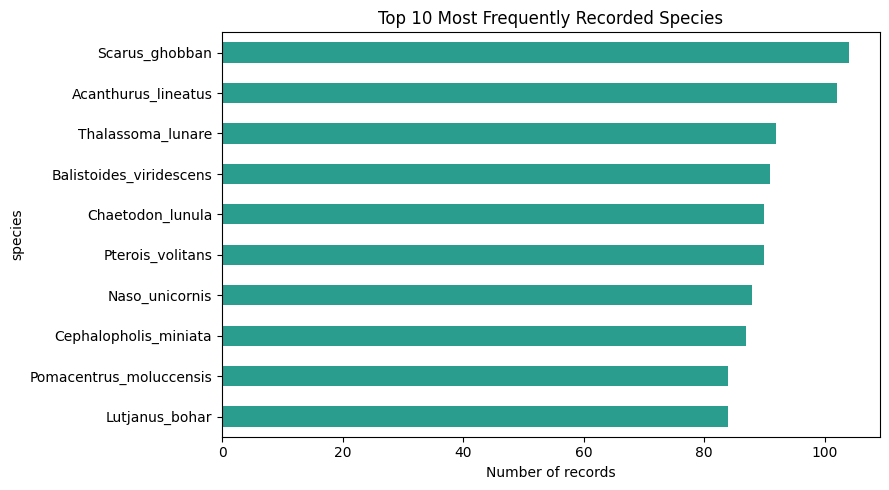

species
Scarus_ghobban             104
Acanthurus_lineatus        102
Thalassoma_lunare           92
Balistoides_viridescens     91
Chaetodon_lunula            90
Pterois_volitans            90
Naso_unicornis              88
Cephalopholis_miniata       87
Pomacentrus_moluccensis     84
Lutjanus_bohar              84
Name: count, dtype: int64


In [ ]:
#Top 10 most frequently recorded species
top_species = df["species"].value_counts().head(10)
plt.figure()
top_species.plot(kind="barh", color="#2a9d8f")
plt.gca().invert_yaxis()
plt.xlabel("Number of records")
plt.title("Top 10 Most Frequently Recorded Species")
plt.tight_layout()
plt.show()
print(top_species)

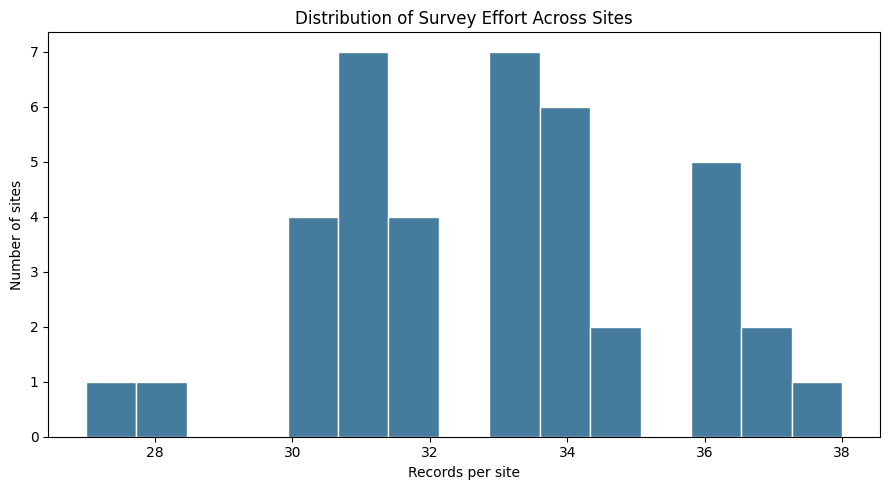

count    40.000000
mean     32.925000
std       2.505251
min      27.000000
25%      31.000000
50%      33.000000
75%      34.250000
max      38.000000
dtype: float64


In [ ]:
#Records per site
records_per_site = df.groupby("siteID").size()
plt.figure()
plt.hist(records_per_site, bins=15, color="#457b9d", edgecolor="white")
plt.xlabel("Records per site")
plt.ylabel("Number of sites")
plt.title("Distribution of Survey Effort Across Sites")
plt.tight_layout()
plt.show()
print(records_per_site.describe())

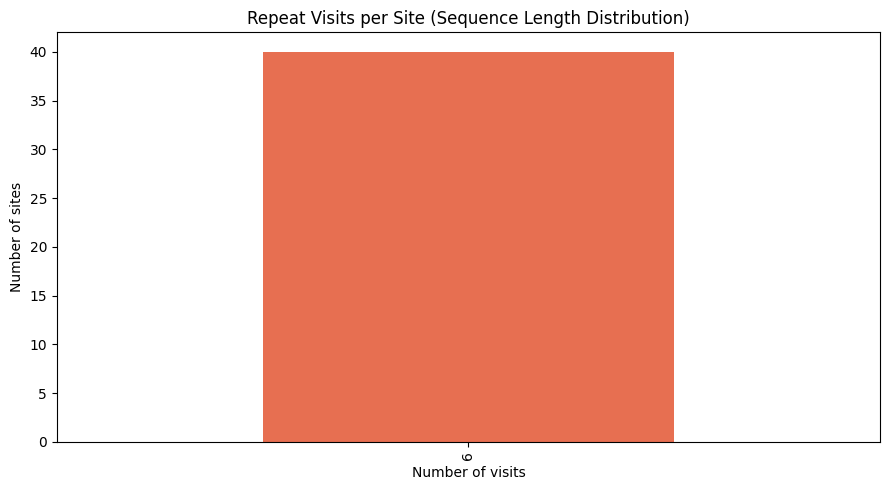

In [ ]:

visits_per_site = df.groupby("siteID")["eventID"].nunique()
plt.figure()
visits_per_site.value_counts().sort_index().plot(kind="bar", color="#e76f51")
plt.xlabel("Number of visits")
plt.ylabel("Number of sites")
plt.title("Repeat Visits per Site (Sequence Length Distribution)")
plt.tight_layout()
plt.show()

## 5. Spatial Pattern Mining — DBSCAN Clustering



In [ ]:
site_coords = df.groupby("siteID")[["decimalLatitude","decimalLongitude"]].mean().reset_index()

eps_km = 60
min_samples = 3
eps_rad = eps_km / 6371.0

coords_rad = np.radians(site_coords[["decimalLatitude","decimalLongitude"]].values)
db = DBSCAN(eps=eps_rad, min_samples=min_samples, metric="haversine").fit(coords_rad)
site_coords["zone"] = db.labels_

n_zones = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = list(db.labels_).count(-1)
print(f"Zones discovered: {n_zones}")
print(f"Noise/outlier sites: {n_noise}")
print(site_coords["zone"].value_counts().sort_index())

Zones discovered: 4
Noise/outlier sites: 0
zone
0    10
1    10
2    10
3    10
Name: count, dtype: int64


### 5a. Clustering Evaluation — Silhouette Score

In [ ]:
#Silhouette score

labels = site_coords["zone"].values
mask = labels != -1
if len(set(labels[mask])) > 1:
    score = silhouette_score(coords_rad[mask], labels[mask], metric="haversine")
    print(f"Silhouette score: {score:.3f}")
    print("(Closer to 1 = well-separated zones; closer to 0 = overlapping zones; negative = poor clustering)")
else:
    print("Not enough clusters to compute a silhouette score — try lowering eps_km.")

Silhouette score: 0.977
(Closer to 1 = well-separated zones; closer to 0 = overlapping zones; negative = poor clustering)


 eps_km  n_zones  n_noise
     10        7       12
     25        4        0
     40        4        0
     60        4        0
     80        4        0
    100        4        0


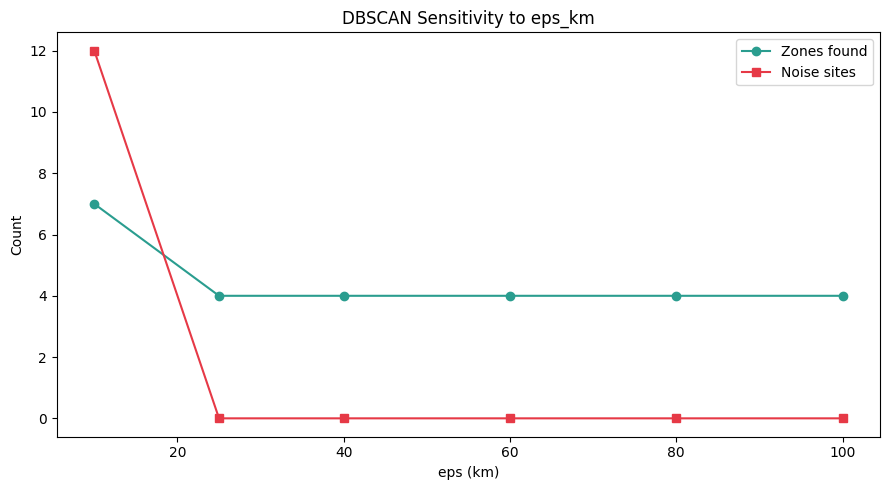

In [ ]:
#eps sensitivity check
eps_range_km = [10, 25, 40, 60, 80, 100]
results = []
for e in eps_range_km:
    labels_test = DBSCAN(eps=e/6371.0, min_samples=min_samples, metric="haversine").fit(coords_rad).labels_
    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    results.append({"eps_km": e, "n_zones": n_clusters, "n_noise": list(labels_test).count(-1)})

eps_df = pd.DataFrame(results)
print(eps_df.to_string(index=False))

plt.figure()
plt.plot(eps_df["eps_km"], eps_df["n_zones"], marker="o", color="#2a9d8f", label="Zones found")
plt.plot(eps_df["eps_km"], eps_df["n_noise"], marker="s", color="#e63946", label="Noise sites")
plt.xlabel("eps (km)")
plt.ylabel("Count")
plt.title("DBSCAN Sensitivity to eps_km")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Merge zone labeling into the main dataframe
df = df.merge(site_coords[["siteID","zone"]], on="siteID", how="left")
df.head()

,eventID,siteID,region,species,decimalLatitude,decimalLongitude,eventDate,individualCount,depth,zone
0,site_001_visit0,site_001,Great_Barrier_North,Chaetodon_lunula,-16.862471,145.919164,2018-01-01,4,16,0
1,site_001_visit0,site_001,Great_Barrier_North,Chlorurus_sordidus,-16.862471,145.919164,2018-01-01,4,10,0
2,site_001_visit0,site_001,Great_Barrier_North,Scarus_ghobban,-16.862471,145.919164,2018-01-01,24,7,0
3,site_001_visit0,site_001,Great_Barrier_North,Lutjanus_bohar,-16.862471,145.919164,2018-01-01,10,7,0
4,site_001_visit0,site_001,Great_Barrier_North,Epinephelus_fuscoguttatus,-16.862471,145.919164,2018-01-01,21,6,0


## 6. Sequential Pattern Mining — PrefixSpan



In [ ]:
def dominant_species(group):
    return group.loc[group["individualCount"].idxmax(), "species"]

visit_summary = (
    df.groupby(["siteID","eventID","eventDate"])
      .apply(dominant_species, include_groups=False)
      .reset_index(name="dominant_species")
      .sort_values(["siteID","eventDate"])
)
print(f"Total site-visits: {len(visit_summary)}")
visit_summary.head(10)

Total site-visits: 240


,siteID,eventID,eventDate,dominant_species
0,site_001,site_001_visit0,2018-01-01,Balistoides_viridescens
1,site_001,site_001_visit1,2018-05-01,Lutjanus_bohar
2,site_001,site_001_visit2,2018-08-29,Cephalopholis_miniata
3,site_001,site_001_visit3,2018-12-27,Chlorurus_sordidus
4,site_001,site_001_visit4,2019-04-26,Plectropomus_leopardus
5,site_001,site_001_visit5,2019-08-24,Plectropomus_leopardus
6,site_002,site_002_visit0,2018-01-01,Naso_unicornis
7,site_002,site_002_visit1,2018-05-01,Chlorurus_sordidus
8,site_002,site_002_visit2,2018-08-29,Plectropomus_leopardus
9,site_002,site_002_visit3,2018-12-27,Epinephelus_fuscoguttatus


In [ ]:
sequences_df = visit_summary.groupby("siteID")["dominant_species"].apply(list).reset_index()
sequences_df = sequences_df[sequences_df["dominant_species"].apply(len) >= 2]

sequences = sequences_df["dominant_species"].tolist()
site_ids_for_sequences = sequences_df["siteID"].tolist()

print(f"Usable sequences (sites with >=2 visits): {len(sequences)}")
for sid, seq in list(zip(site_ids_for_sequences, sequences))[:5]:
    print(sid, "->", seq)

Usable sequences (sites with >=2 visits): 40
site_001 -> [np.str_('Balistoides_viridescens'), np.str_('Lutjanus_bohar'), np.str_('Cephalopholis_miniata'), np.str_('Chlorurus_sordidus'), np.str_('Plectropomus_leopardus'), np.str_('Plectropomus_leopardus')]
site_002 -> [np.str_('Naso_unicornis'), np.str_('Chlorurus_sordidus'), np.str_('Plectropomus_leopardus'), np.str_('Epinephelus_fuscoguttatus'), np.str_('Pomacentrus_moluccensis'), np.str_('Naso_unicornis')]
site_003 -> [np.str_('Thalassoma_lunare'), np.str_('Pterois_volitans'), np.str_('Pterois_volitans'), np.str_('Scarus_ghobban'), np.str_('Lutjanus_bohar'), np.str_('Chaetodon_lunula')]
site_004 -> [np.str_('Chaetodon_lunula'), np.str_('Chaetodon_lunula'), np.str_('Scarus_ghobban'), np.str_('Zebrasoma_scopas'), np.str_('Naso_unicornis'), np.str_('Scarus_ghobban')]
site_005 -> [np.str_('Chlorurus_sordidus'), np.str_('Cephalopholis_miniata'), np.str_('Acanthurus_lineatus'), np.str_('Scarus_ghobban'), np.str_('Acanthurus_lineatus'), np.

### 6a. Mining with Justified min_support

In [ ]:
min_support = max(3, int(0.15 * len(sequences)))
ps = PrefixSpan(sequences)
patterns = ps.frequent(min_support)
patterns_sorted = sorted(patterns, key=lambda x: -x[0])
multi_step = [(s,p) for s,p in patterns_sorted if len(p) >= 2]

print(f"min_support used: {min_support}")
print(f"Total frequent patterns: {len(patterns_sorted)}")
print(f"Multi-step (length >=2) patterns: {len(multi_step)}\n")
for support, pattern in multi_step[:15]:
    print(f"  support={support:<3}  {' -> '.join(pattern)}")

min_support used: 6
Total frequent patterns: 20
Multi-step (length >=2) patterns: 5

  support=7    Scarus_ghobban -> Acanthurus_lineatus
  support=6    Epinephelus_fuscoguttatus -> Scarus_ghobban
  support=6    Scarus_ghobban -> Naso_unicornis
  support=6    Acanthurus_lineatus -> Acanthurus_lineatus
  support=6    Caranx_melampygus -> Chlorurus_sordidus


### 6b. Support Threshold Sensitivity (evaluation)

 min_support  n_patterns
           2         230
           3         102
           4          56
           5          33
           6          20
           7          16
           8          15
           9          15


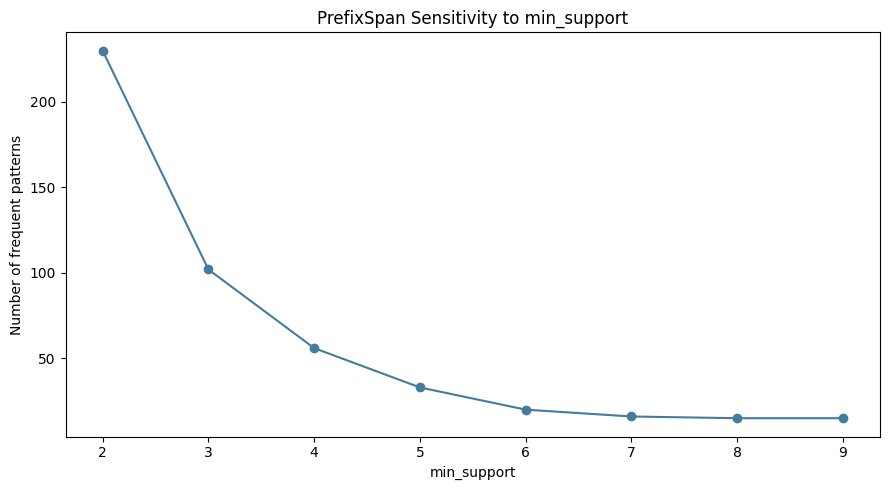

In [ ]:
support_range = range(2, min(10, len(sequences)))
sensitivity = []
for sup in support_range:
    n_patterns = len(ps.frequent(sup))
    sensitivity.append({"min_support": sup, "n_patterns": n_patterns})

sens_df = pd.DataFrame(sensitivity)
print(sens_df.to_string(index=False))

plt.figure()
plt.plot(sens_df["min_support"], sens_df["n_patterns"], marker="o", color="#457b9d")
plt.xlabel("min_support")
plt.ylabel("Number of frequent patterns")
plt.title("PrefixSpan Sensitivity to min_support")
plt.tight_layout()
plt.show()

## 7. Spatio-Sequential Fusion (Novel Contribution)



In [ ]:
zone_lookup = dict(zip(site_coords["siteID"], site_coords["zone"]))

pattern_zone_rows = []
for support, pattern in multi_step:
    for sid, seq in zip(site_ids_for_sequences, sequences):
        it = iter(seq)
        if all(any(elem == p for elem in it) for p in pattern):
            pattern_zone_rows.append({"pattern": " -> ".join(pattern), "siteID": sid, "zone": zone_lookup.get(sid)})

pattern_zone_df = pd.DataFrame(pattern_zone_rows)
if not pattern_zone_df.empty:
    zone_pattern_counts = (pattern_zone_df.groupby(["pattern","zone"]).size()
                            .reset_index(name="count").sort_values("count", ascending=False))
    print(zone_pattern_counts.to_string(index=False))
else:
    print("No multi-step patterns met the support threshold.")

                                    pattern  zone  count
 Acanthurus_lineatus -> Acanthurus_lineatus     0      2
 Acanthurus_lineatus -> Acanthurus_lineatus     1      2
    Caranx_melampygus -> Chlorurus_sordidus     2      2
    Caranx_melampygus -> Chlorurus_sordidus     0      2
           Scarus_ghobban -> Naso_unicornis     3      2
      Scarus_ghobban -> Acanthurus_lineatus     3      2
Epinephelus_fuscoguttatus -> Scarus_ghobban     2      2
Epinephelus_fuscoguttatus -> Scarus_ghobban     0      2
           Scarus_ghobban -> Naso_unicornis     0      2
      Scarus_ghobban -> Acanthurus_lineatus     0      2
      Scarus_ghobban -> Acanthurus_lineatus     1      2
 Acanthurus_lineatus -> Acanthurus_lineatus     2      1
 Acanthurus_lineatus -> Acanthurus_lineatus     3      1
Epinephelus_fuscoguttatus -> Scarus_ghobban     1      1
    Caranx_melampygus -> Chlorurus_sordidus     1      1
    Caranx_melampygus -> Chlorurus_sordidus     3      1
Epinephelus_fuscoguttatus -> Sc

In [ ]:
#Species richness per zone
richness = df.groupby("zone")["species"].nunique().reset_index(name="species_richness")
print(richness.to_string(index=False))

 zone  species_richness
    0                15
    1                15
    2                15
    3                15


## 8. Visualization

In [ ]:
#Map: reef sites colored by zone
center_lat, center_lon = site_coords["decimalLatitude"].mean(), site_coords["decimalLongitude"].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=4, tiles="CartoDB positron")
palette = ["red","blue","green","purple","orange","darkred","cadetblue","darkgreen","pink","gray"]
for _, row in site_coords.iterrows():
    zone = row["zone"]
    color = "black" if zone == -1 else palette[int(zone) % len(palette)]
    folium.CircleMarker(location=[row["decimalLatitude"], row["decimalLongitude"]], radius=6,
        color=color, fill=True, fill_opacity=0.8, popup=f"Site: {row['siteID']} | Zone: {zone}").add_to(m)
m

## 8. GIS-Based Geographic Visualization — Locating Reef Fish Survey Sites



### 8a. Individual Species Location Map


In [ ]:
#Choose a species to locate geographically
target_species = df["species"].value_counts().idxmax()
print(f"Locating species: {target_species}")

species_sites = df[df["species"] == target_species].groupby("siteID")[
    ["decimalLatitude", "decimalLongitude"]].mean().reset_index()
species_sites["count"] = df[df["species"] == target_species].groupby("siteID")["individualCount"].sum().values

m_species = folium.Map(location=[center_lat, center_lon], zoom_start=4, tiles="CartoDB positron")
for _, row in species_sites.iterrows():
    folium.CircleMarker(
        location=[row["decimalLatitude"], row["decimalLongitude"]],
        radius=6 + row["count"] * 0.15,
        color="#e63946", fill=True, fill_opacity=0.8,
        popup=f"Site: {row['siteID']}<br>{target_species} count: {row['count']}"
    ).add_to(m_species)

m_species

Locating species: Scarus_ghobban


### 8b. Zone Boundary Polygons (Convex Hulls)



In [ ]:
from scipy.spatial import ConvexHull

m2 = folium.Map(location=[center_lat, center_lon], zoom_start=4, tiles="CartoDB positron")

for zone_id in sorted(site_coords["zone"].unique()):
    if zone_id == -1:
        continue
    zone_pts = site_coords[site_coords["zone"] == zone_id][["decimalLatitude","decimalLongitude"]].values
    color = palette[int(zone_id) % len(palette)]

    for lat, lon in zone_pts:
        folium.CircleMarker(location=[lat, lon], radius=5, color=color,
                             fill=True, fill_opacity=0.9).add_to(m2)

    if len(zone_pts) >= 3:
        hull = ConvexHull(zone_pts)
        hull_coords = zone_pts[hull.vertices].tolist()
        hull_coords.append(hull_coords[0])
        folium.Polygon(locations=hull_coords, color=color, weight=2,
                        fill=True, fill_opacity=0.15,
                        popup=f"Zone {zone_id} boundary ({len(zone_pts)} sites)").add_to(m2)

m2

### 8c. Survey Density Heatmap



In [ ]:
from folium.plugins import HeatMap

m3 = folium.Map(location=[center_lat, center_lon], zoom_start=4, tiles="CartoDB dark_matter")
heat_data = df[["decimalLatitude","decimalLongitude"]].values.tolist()
HeatMap(heat_data, radius=15, blur=20).add_to(m3)
m3

### 8d. Layered Interactive Zone Map



In [ ]:
m4 = folium.Map(location=[center_lat, center_lon], zoom_start=4, tiles="CartoDB positron")

for zone_id in sorted(site_coords["zone"].unique()):
    label = "Noise/Outliers" if zone_id == -1 else f"Zone {zone_id}"
    color = "black" if zone_id == -1 else palette[int(zone_id) % len(palette)]
    fg = folium.FeatureGroup(name=label, show=True)

    zone_sites = site_coords[site_coords["zone"] == zone_id]
    for _, row in zone_sites.iterrows():
        richness_here = df[df["siteID"] == row["siteID"]]["species"].nunique()
        folium.CircleMarker(
            location=[row["decimalLatitude"], row["decimalLongitude"]],
            radius=6 + richness_here * 0.3,
            color=color, fill=True, fill_opacity=0.75,
            popup=f"Site: {row['siteID']}<br>Zone: {zone_id}<br>Species recorded: {richness_here}"
        ).add_to(fg)
    fg.add_to(m4)

folium.LayerControl(collapsed=False).add_to(m4)
m4

### 8e. Bathymetric (Depth vs. Location) View


/tmp/ipykernel_4459/454111257.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(depth_by_zone, labels=[f"Zone {z}" for z in zone_order])


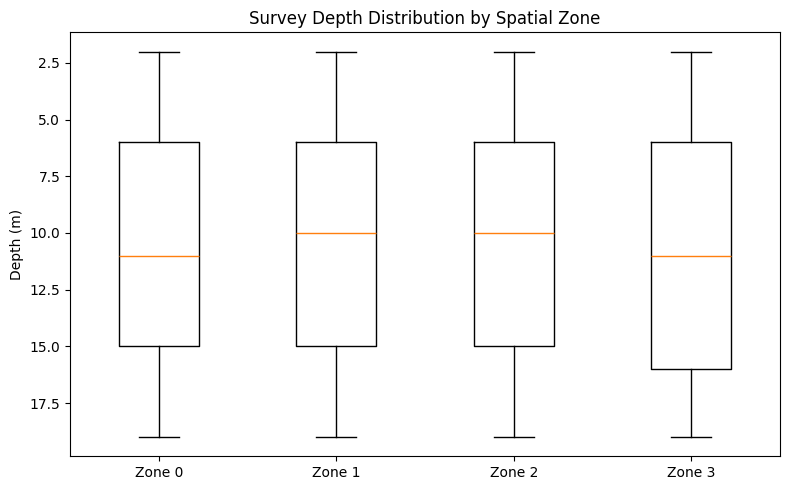

In [ ]:
plt.figure(figsize=(8,5))
zone_order = sorted([z for z in df["zone"].unique() if z != -1])
depth_by_zone = [df[df["zone"]==z]["depth"].dropna().values for z in zone_order]
plt.boxplot(depth_by_zone, labels=[f"Zone {z}" for z in zone_order])
plt.ylabel("Depth (m)")
plt.title("Survey Depth Distribution by Spatial Zone")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

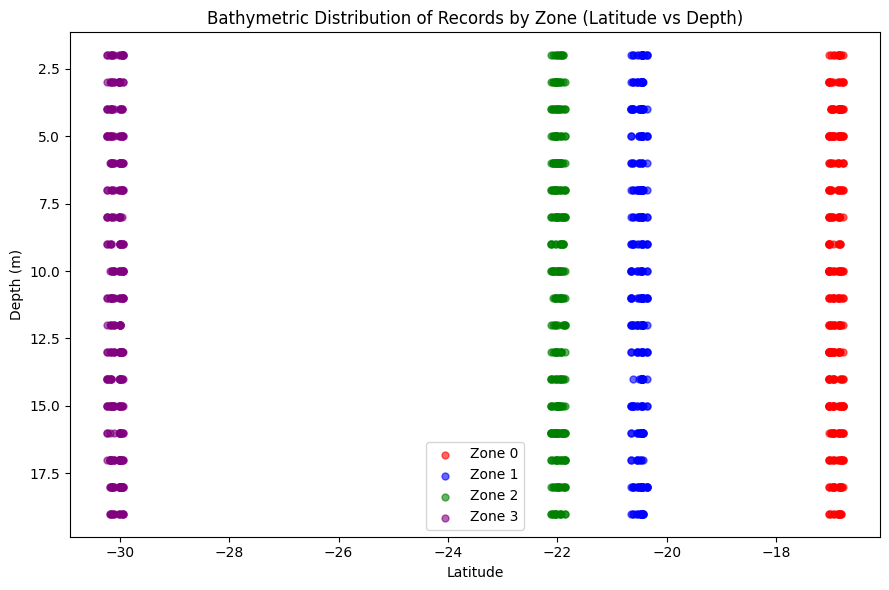

In [ ]:
plt.figure(figsize=(9,6))
for zone_id in zone_order:
    sub = df[df["zone"] == zone_id]
    plt.scatter(sub["decimalLatitude"], sub["depth"],
                color=palette[int(zone_id) % len(palette)], label=f"Zone {zone_id}", alpha=0.6, s=25)
plt.xlabel("Latitude")
plt.ylabel("Depth (m)")
plt.title("Bathymetric Distribution of Records by Zone (Latitude vs Depth)")
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

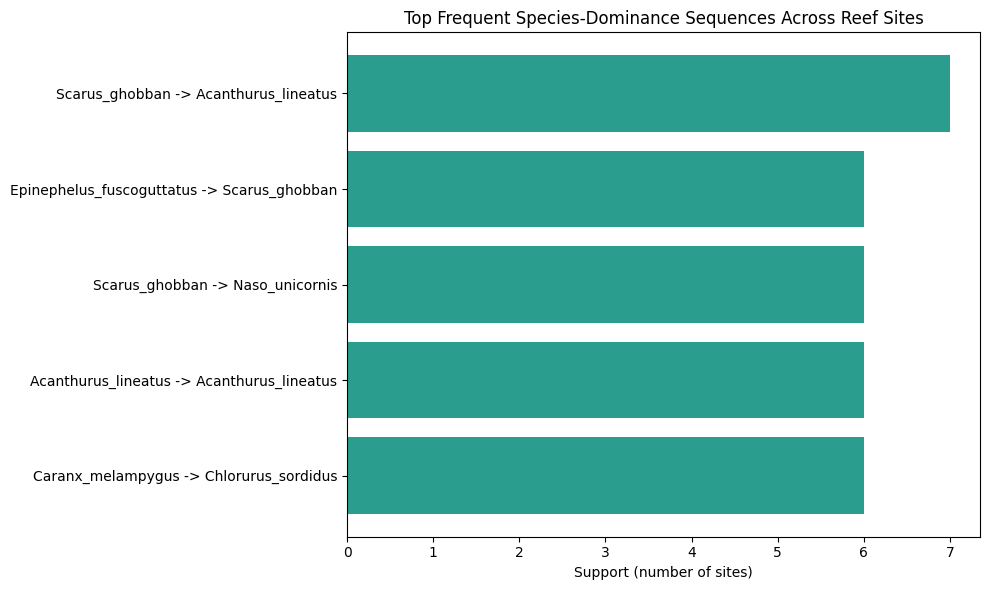

In [ ]:
#Frequent pattern bar chart
if multi_step:
    labels = [" -> ".join(p) for s,p in multi_step]
    supports = [s for s,p in multi_step]
    plt.figure(figsize=(10,6))
    plt.barh(labels, supports, color="#2a9d8f")
    plt.xlabel("Support (number of sites)")
    plt.title("Top Frequent Species-Dominance Sequences Across Reef Sites")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

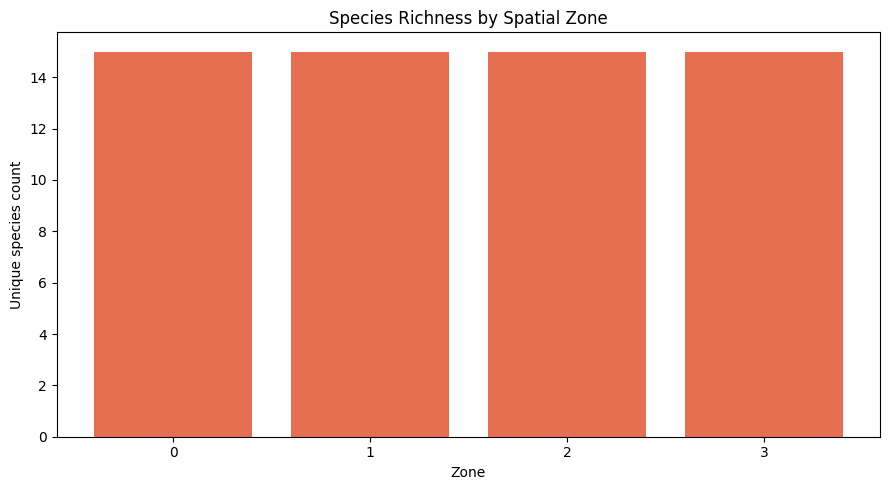

In [ ]:
#Species richness per zone
richness = df.groupby("zone")["species"].nunique().reset_index(name="species_richness")
#Species richness by zone
plt.figure()
plt.bar(richness["zone"].astype(str), richness["species_richness"], color="#e76f51")
plt.xlabel("Zone")
plt.ylabel("Unique species count")
plt.title("Species Richness by Spatial Zone")
plt.tight_layout()
plt.show()

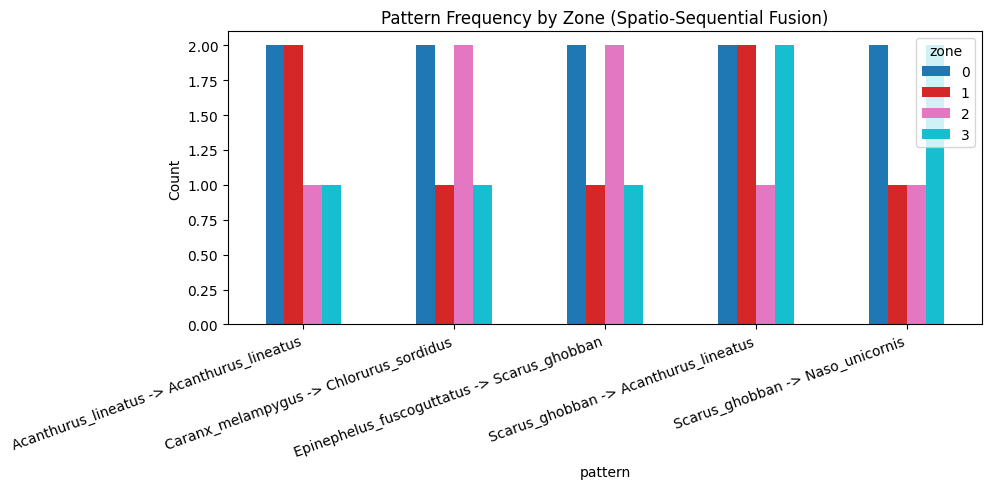

In [ ]:
#Zone x pattern fusion chart
if not pattern_zone_df.empty:
    pivot = zone_pattern_counts.pivot(index="pattern", columns="zone", values="count").fillna(0)
    pivot.plot(kind="bar", figsize=(10,5), colormap="tab10")
    plt.ylabel("Count")
    plt.title("Pattern Frequency by Zone (Spatio-Sequential Fusion)")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()